Для Python 3.10 следующий набор версий библиотек рабочий и не падает с ошибками при выполнении данного ноутбука:

<ul>
    <li>pandas==2.0.3</li>
    <li>numpy==1.24.4</li>
    <li>statsmodels==0.14.4</li>
    <li>matplotlib==3.10.0</li>
    <li>scipy==1.10.1</li>
    <li>statsmodels==0.14.4</li>
    <li>sklearn==1.6.1</li>
    <li>arch==7.2.0</li>
</ul>


# Лекция 4

In [1]:
import pandas as pd
import numpy as np
import tqdm
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

In [2]:
%matplotlib inline

In [3]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [4]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)
        
        plt.tight_layout()
    return

In [5]:
series = pd.read_csv('Series/international-airline-passengers.csv').dropna().values[:, 1].astype(float)
print(series)

[112. 118. 132. 129. 121. 135. 148. 148. 136. 119. 104. 118. 115. 126.
 141. 135. 125. 149. 170. 170. 158. 133. 114. 140. 145. 150. 178. 163.
 172. 178. 199. 199. 184. 162. 146. 166. 171. 180. 193. 181. 183. 218.
 230. 242. 209. 191. 172. 194. 196. 196. 236. 235. 229. 243. 264. 272.
 237. 211. 180. 201. 204. 188. 235. 227. 234. 264. 302. 293. 259. 229.
 203. 229. 242. 233. 267. 269. 270. 315. 364. 347. 312. 274. 237. 278.
 284. 277. 317. 313. 318. 374. 413. 405. 355. 306. 271. 306. 315. 301.
 356. 348. 355. 422. 465. 467. 404. 347. 305. 336. 340. 318. 362. 348.
 363. 435. 491. 505. 404. 359. 310. 337. 360. 342. 406. 396. 420. 472.
 548. 559. 463. 407. 362. 405. 417. 391. 419. 461. 472. 535. 622. 606.
 508. 461. 390. 432.]


Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


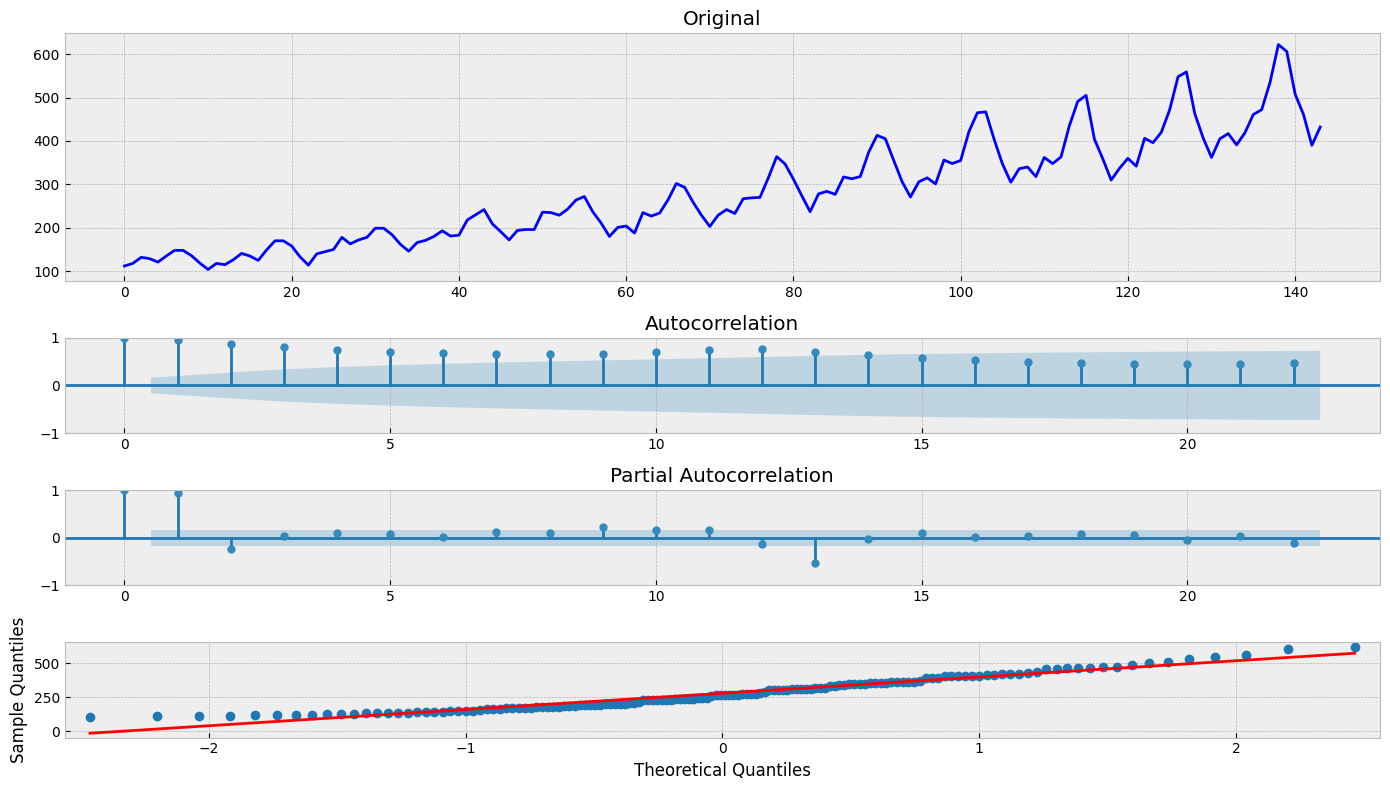

In [6]:
tsplot(series)

## ARCH

AutoRegressive Conditional Heteroscedasticit - пытаемся объяснить дисперсию в ряде через предыдущие значения (применяя к ним AR)

Пусть временной ряд представляется в таком виде:

$u_t = \epsilon_t * \sqrt{\alpha_0 + \sum_{i=1}^q \alpha_i u_{t-i}^2}$

Тогда условная дисперсия ряда будет равна

$\sigma_t^2 = V(u_t | u_{t-1}, ..., u_{t-q}) = \alpha_0 + \sum_{i=1}^q \alpha_i u_{t-i}^2$

Получили модель ARCH(q) условной дисперсии. Требуем, чтобы все коэффициенты были больше 0 (иначе может получится отрицательная дисперсия)

Results of Dickey-Fuller Test:
Test Statistic                 -31.510128
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    999.000000
Critical Value (1%)             -3.436913
Critical Value (5%)             -2.864437
Critical Value (10%)            -2.568313
dtype: float64


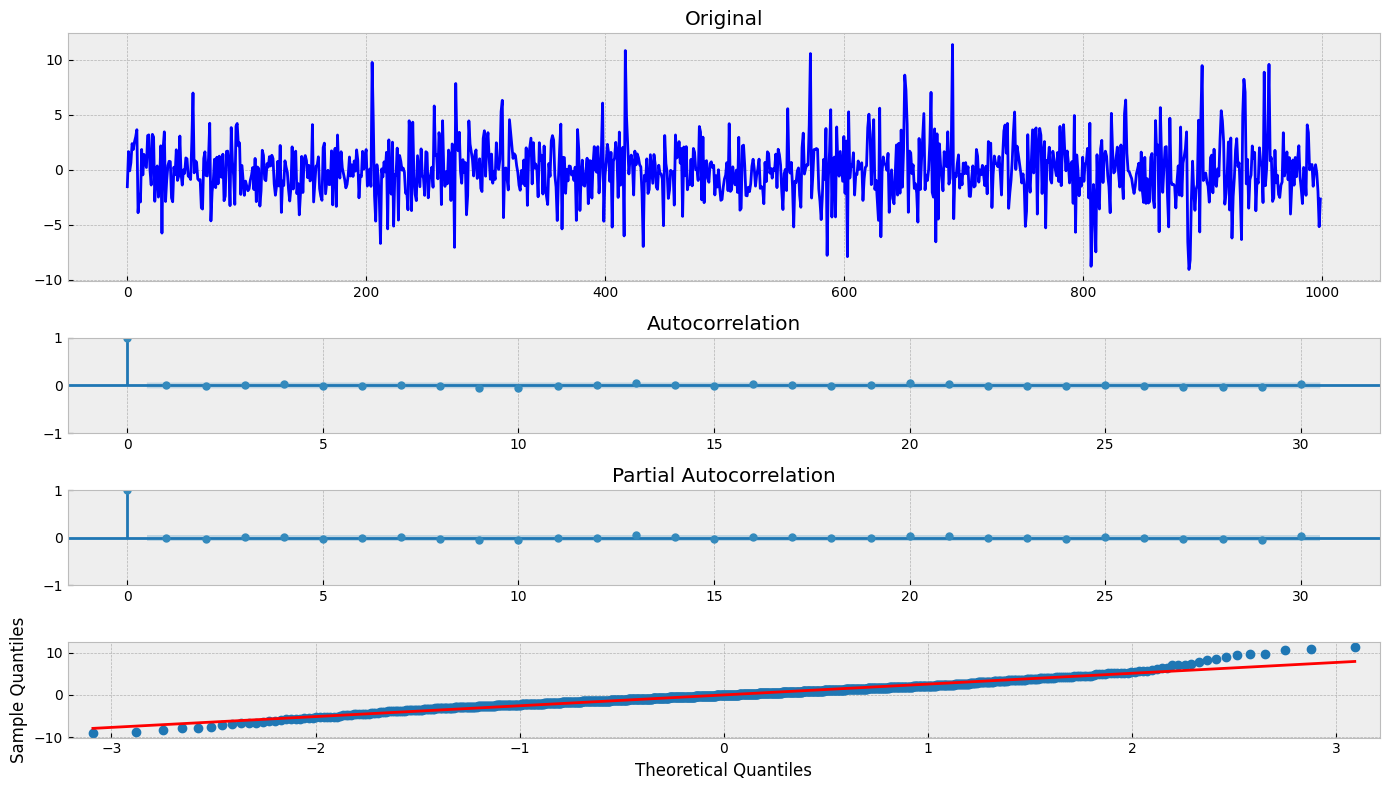

In [7]:
# Simulate ARCH(1) series
# Var(yt) = a_0 + a_1*y{t-1}**2
# if a_1 is between 0 and 1 then yt is white noise

np.random.seed(13)

a0 = 2
a1 = 5.5

y = w = np.random.normal(size=1000)
Y = np.empty_like(y)

for t in range(len(y)):
    Y[t] = w[t] * np.sqrt((a0 + a1*y[t-1]**2))

# simulated ARCH(1) series, looks like white noise
tsplot(Y, lags=30)

## GARCH

Добавляем зависимость от прошлых значений самой условной дисперсии. Получаем модель GARCH(p, q)

$\sigma_t^2 = V(u_t | u_{t-1}, ..., u_{t-q}) = \alpha_0 + \sum_{i=1}^q \alpha_i u_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2$

GARCH - по сути - модель ARMA примененная к дисперсии ряда

In [8]:
from arch import arch_model

## Практика! Реализуйте процесс GARCH, нарисуйте его график, примените к нему модель ARIMA и посмотрите на график остатков

Results of Dickey-Fuller Test:
Test Statistic                  -96.275609
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    9999.000000
Critical Value (1%)              -3.431004
Critical Value (5%)              -2.861829
Critical Value (10%)             -2.566924
dtype: float64


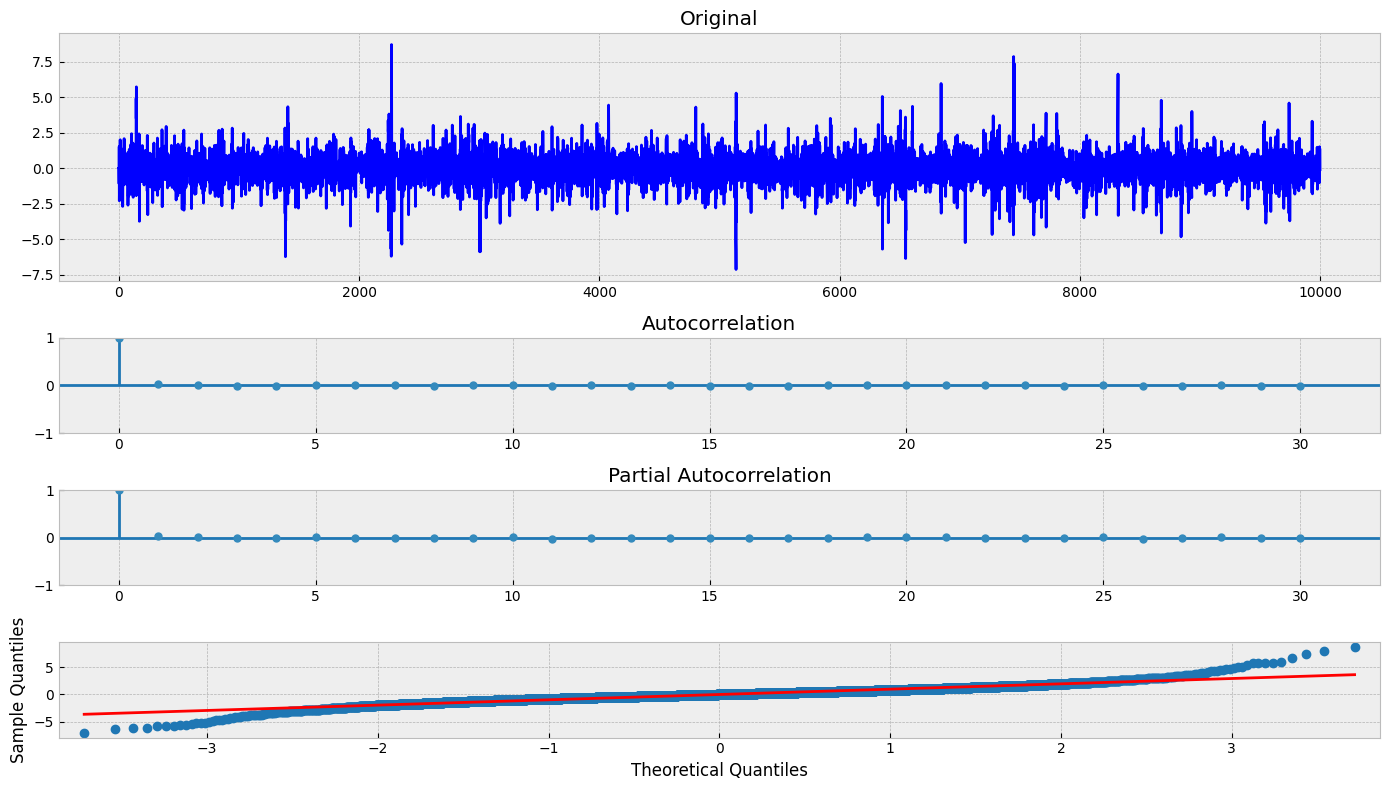

In [9]:
# Simulating a GARCH(1, 1) process

np.random.seed(2)

a0 = 0.2
a1 = 0.5
b1 = 0.3

n = 10000
w = np.random.normal(size=n)
eps = np.zeros_like(w)
sigsq = np.zeros_like(w)

for i in range(1, n):
    sigsq[i] = a0 + a1*(eps[i-1]**2) + b1*sigsq[i-1]
    eps[i] = w[i] * np.sqrt(sigsq[i])

tsplot(eps, lags=30)

In [10]:
am = arch_model(eps)
res = am.fit(update_freq=5)
print(res.summary())

Iteration:      5,   Func. Count:     34,   Neg. LLF: 13129.779353976788
Iteration:     10,   Func. Count:     62,   Neg. LLF: 12237.31278031168
Optimization terminated successfully    (Exit mode 0)
            Current function value: 12237.3032673183
            Iterations: 13
            Function evaluations: 76
            Gradient evaluations: 13
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -12237.3
Distribution:                  Normal   AIC:                           24482.6
Method:            Maximum Likelihood   BIC:                           24511.4
                                        No. Observations:                10000
Date:                Mon, May 18 2026   Df Residuals:                     9999
Time:          

# Продолжаем анализировать полеты

Применим ARIMA к нашему временному ряду

In [11]:
from statsmodels.tsa.arima.model import ARIMA

In [12]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [13]:
def _get_best_model(TS):
    best_aic = np.inf 
    best_order = None
    best_mdl = None

    for i in range(5):
        for d in range(5):
            for j in range(5):
                # try:
                tmp_mdl = ARIMA(TS, order=(i, d, j), trend='n').fit()
                tmp_aic = tmp_mdl.aic
                if tmp_aic < best_aic:
                    best_aic = tmp_aic
                    best_order = (i, d, j)
                    best_mdl = tmp_mdl
                # except: continue
    print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))                    
    return best_aic, best_order, best_mdl

aic, order, mdl = _get_best_model(series.astype(float))

aic: 1342.39033 | order: (4, 1, 4)


Results of Dickey-Fuller Test:
Test Statistic                  -4.981439
p-value                          0.000024
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


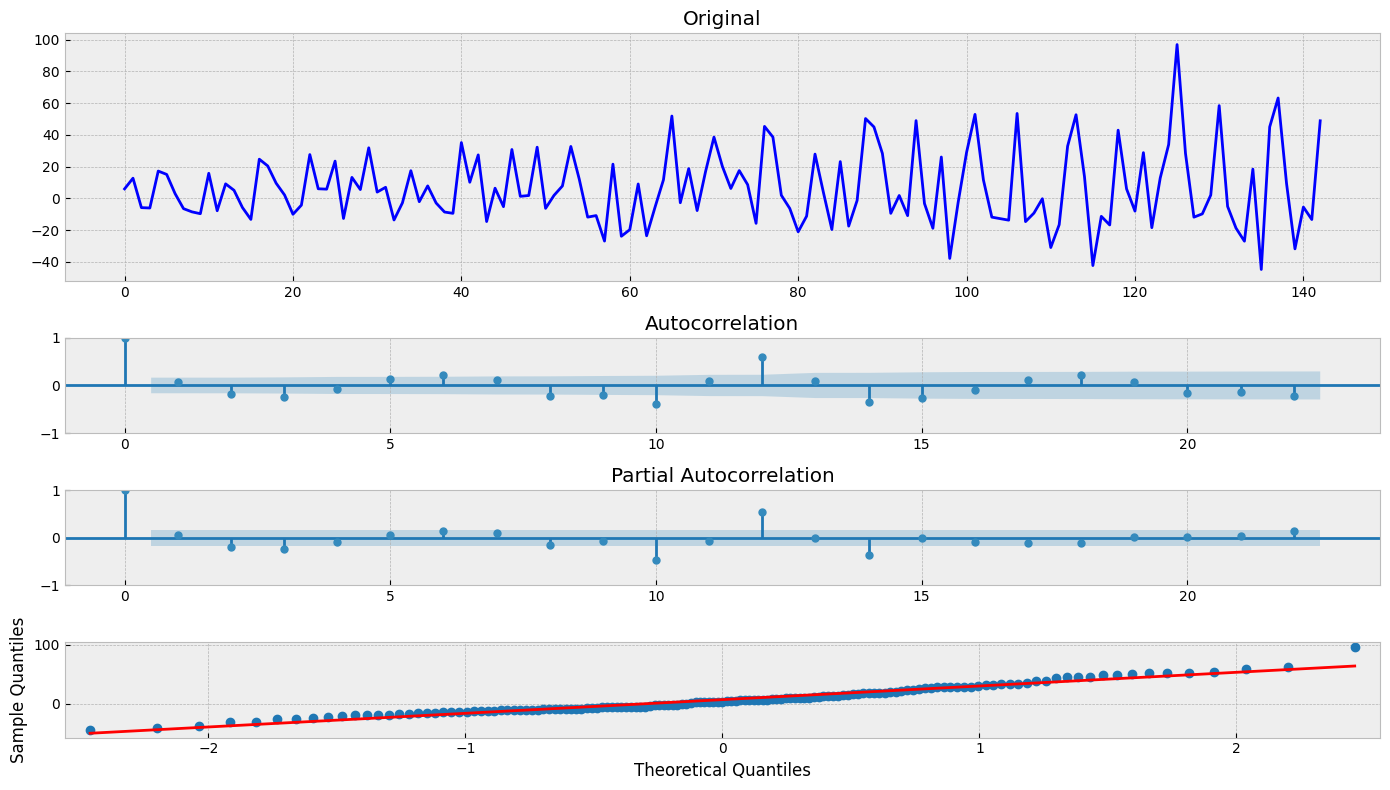

In [14]:
tsplot(mdl.resid[1:])

Применим GARCH

In [15]:
series = series[12:] - series[:-12]
series = series[1:] - series[:-1]

In [16]:
# Now we can fit the arch model using the best fit arima model parameters
p_ = 4
o_ = 1
q_ = 4

# Using student T distribution usually provides better fit
am = arch_model(series, dist='StudentsT')
res = am.fit(update_freq=5, disp='off')
print(res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -507.387
Distribution:      Standardized Student's t   AIC:                           1024.77
Method:                  Maximum Likelihood   BIC:                           1039.15
                                              No. Observations:                  131
Date:                      Mon, May 18 2026   Df Residuals:                      130
Time:                              23:25:18   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

Results of Dickey-Fuller Test:
Test Statistic                -1.559562e+01
p-value                        1.856512e-28
#Lags Used                     0.000000e+00
Number of Observations Used    1.300000e+02
Critical Value (1%)           -3.481682e+00
Critical Value (5%)           -2.884042e+00
Critical Value (10%)          -2.578770e+00
dtype: float64


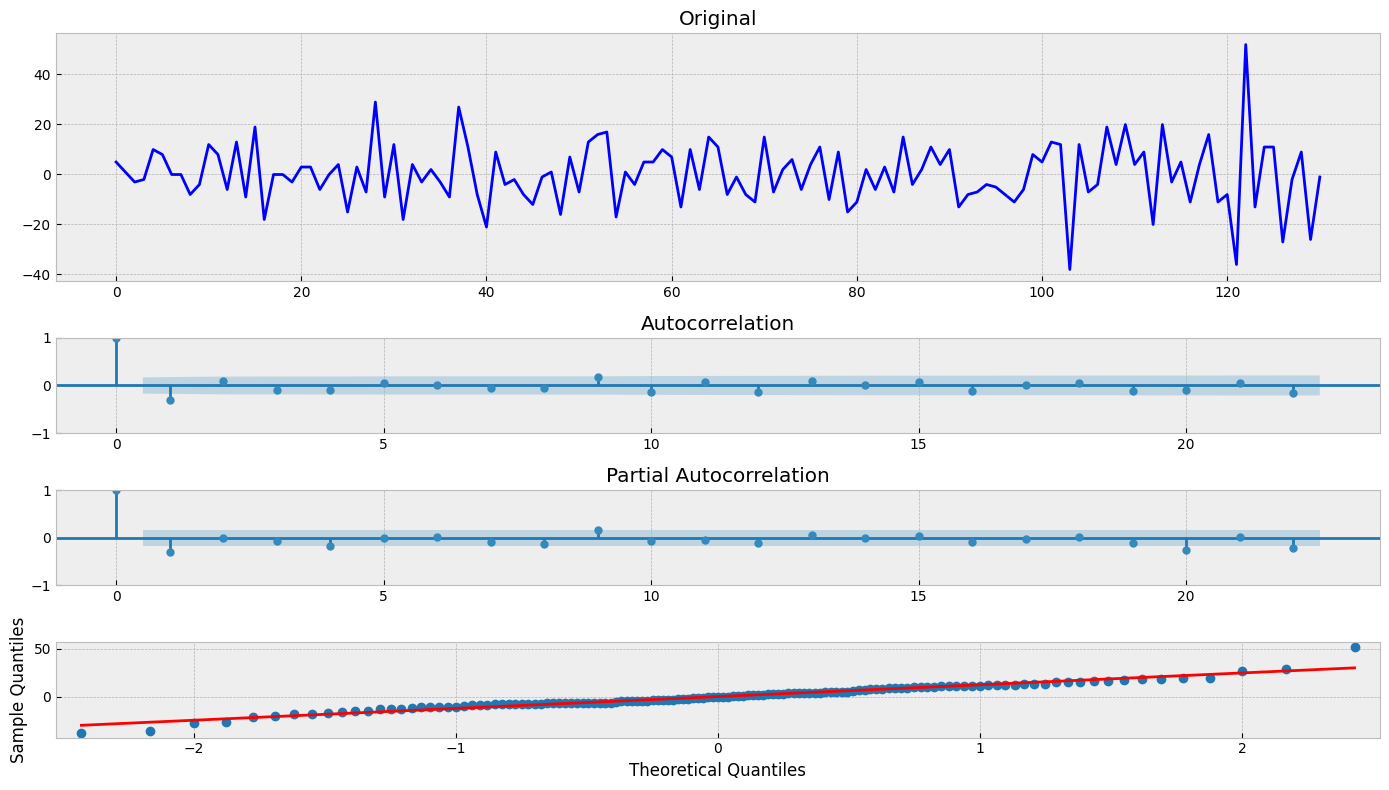

In [17]:
tsplot(res.resid)

## Проведем анализ для monthly-boston-armed-robberies-j

Results of Dickey-Fuller Test:
Test Statistic                -1.214226e+01
p-value                        1.640728e-22
#Lags Used                     1.100000e+01
Number of Observations Used    2.270000e+02
Critical Value (1%)           -3.459490e+00
Critical Value (5%)           -2.874358e+00
Critical Value (10%)          -2.573602e+00
dtype: float64


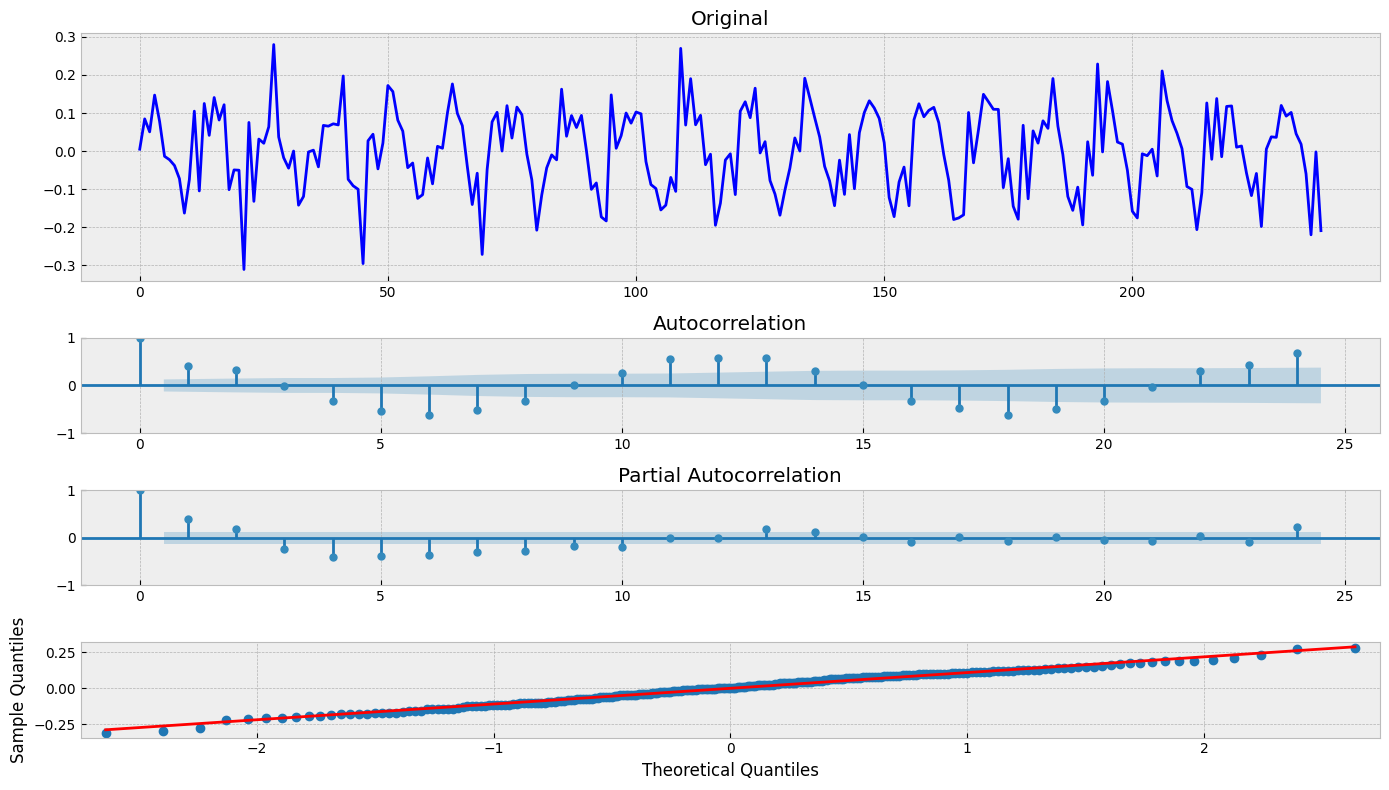

In [18]:
new_series = pd.read_csv("Series/mean-monthly-air-temperature-deg.csv").Deg.astype('float64')
new_series = boxcox(new_series, 0)
new_series = new_series[1:] - new_series[:-1]
tsplot(new_series)

In [19]:
aic, order, mdl = _get_best_model(new_series)

aic: -704.27383 | order: (2, 0, 4)


Results of Dickey-Fuller Test:
Test Statistic                -1.521342e+01
p-value                        5.613288e-28
#Lags Used                     0.000000e+00
Number of Observations Used    2.370000e+02
Critical Value (1%)           -3.458247e+00
Critical Value (5%)           -2.873814e+00
Critical Value (10%)          -2.573311e+00
dtype: float64


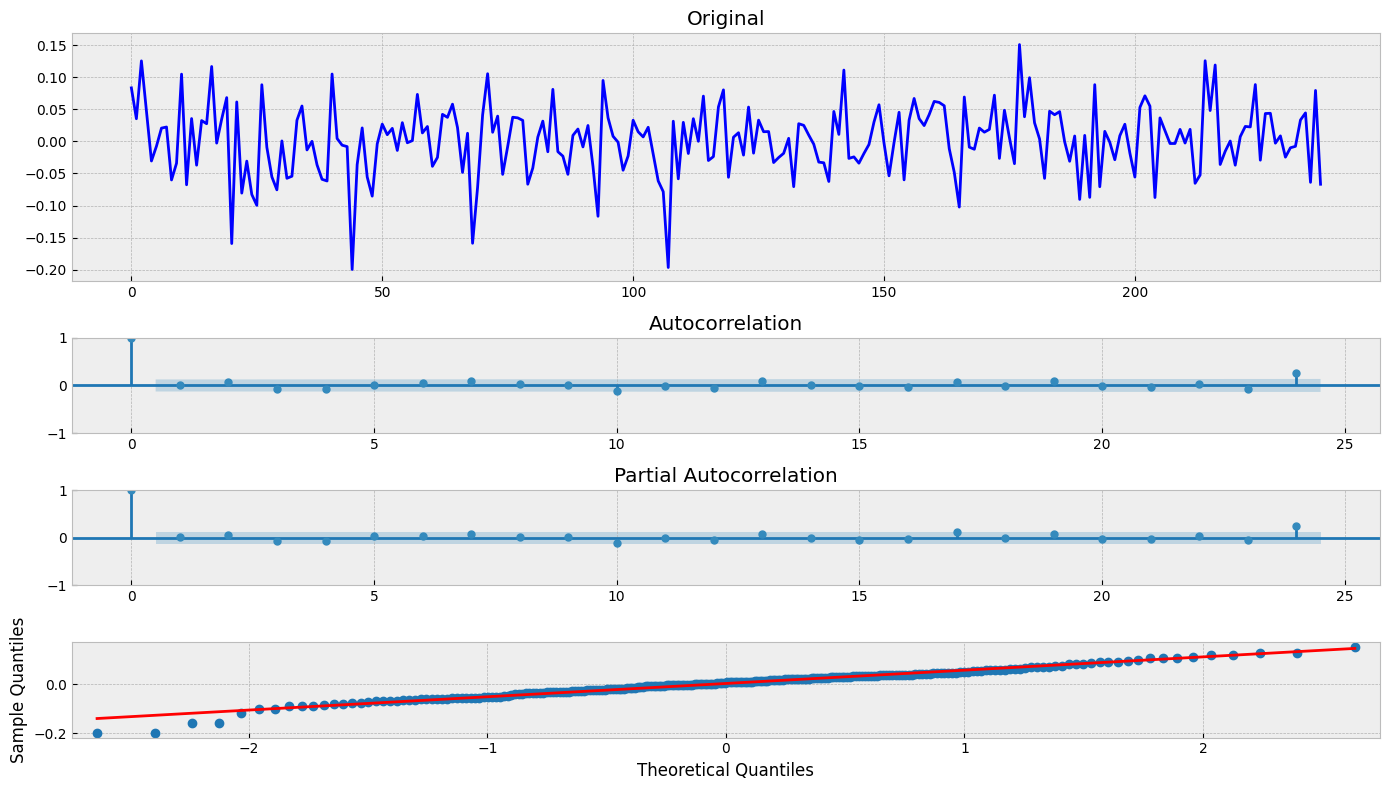

In [20]:
tsplot(mdl.resid[1:])

In [21]:
order

(2, 0, 4)

In [22]:
# Now we can fit the arch model using the best fit arima model parameters
p_ = order[0]
o_ = order[1]
q_ = order[2]

# Using student T distribution usually provides better fit
am = arch_model(new_series*100, p=p_, o=o_, q=q_, dist='StudentsT')
res = am.fit(update_freq=5)
print(res.summary())

Iteration:      5,   Func. Count:     53,   Neg. LLF: 911.2996957311198
Iteration:     10,   Func. Count:    103,   Neg. LLF: 910.1128368569134
Iteration:     15,   Func. Count:    153,   Neg. LLF: 909.5968739471818
Iteration:     20,   Func. Count:    203,   Neg. LLF: 909.567469192725
Optimization terminated successfully    (Exit mode 0)
            Current function value: 909.5670500637241
            Iterations: 22
            Function evaluations: 234
            Gradient evaluations: 22
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -909.567
Distribution:      Standardized Student's t   AIC:                           1837.13
Method:                  Maximum Likelihood   BIC:                           1

In [23]:
forecast = res.forecast(horizon=100)

In [24]:
new_series.shape

(239,)

In [25]:
new_series[-5:]

array([ 0.01795967, -0.06001801, -0.22014119, -0.00214362, -0.20929144])

In [26]:
forecast

In [27]:
forecast.residual_variance.iloc[-1]

h.001    113.996570
h.002    128.166053
h.003    117.709286
h.004    125.084242
h.005    116.799245
            ...    
h.096    120.057699
h.097    120.057691
h.098    120.057697
h.099    120.057692
h.100    120.057696
Name: 238, Length: 100, dtype: float64

[113.99656967 128.16605301 117.70928617 125.08424244 116.79924489
 124.46989303 118.72895764 122.82946726 118.30408964 122.45964224
 119.30843007 121.5852479  119.11299015 121.36581122 119.63643475
 120.89910458 119.54826508 120.77037111 119.82146132 120.52093973
 119.78272995 120.44610483 119.92552204 120.31262607 119.90915056
 120.2694482  119.98389323 120.1979311  119.97737883 120.17317357
 120.01655988 120.13480937 120.01423396 120.12068832 120.03480387
 120.10008476 120.03415902 120.09206653 120.0449744  120.0809891
 120.0449398  120.07645372 120.05063497 120.07049165 120.05077737
 120.06793485 120.05378086 120.06472269 120.05394057 120.0632855
 120.05552693 120.06155322 120.05565578 120.06074744 120.0564949
 120.05981237 120.05658643 120.05936162 120.05703095 120.05885644
 120.05709169 120.05860479 120.05732752 120.05833163 120.05736617
 120.05819139 120.05749146 120.05804357 120.05751535 120.05796554
 120.05758201 120.05788548 120.05759647 120.05784213 120.05763199
 120.05779875

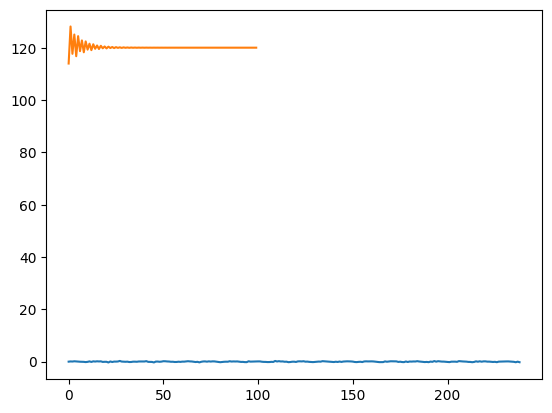

In [28]:
plt.plot(new_series)
print(forecast.residual_variance.iloc[-1].values)
plt.plot([0]*100 + forecast.residual_variance.iloc[-1].values)
plt.show()

Results of Dickey-Fuller Test:
Test Statistic                -1.214226e+01
p-value                        1.640728e-22
#Lags Used                     1.100000e+01
Number of Observations Used    2.270000e+02
Critical Value (1%)           -3.459490e+00
Critical Value (5%)           -2.874358e+00
Critical Value (10%)          -2.573602e+00
dtype: float64


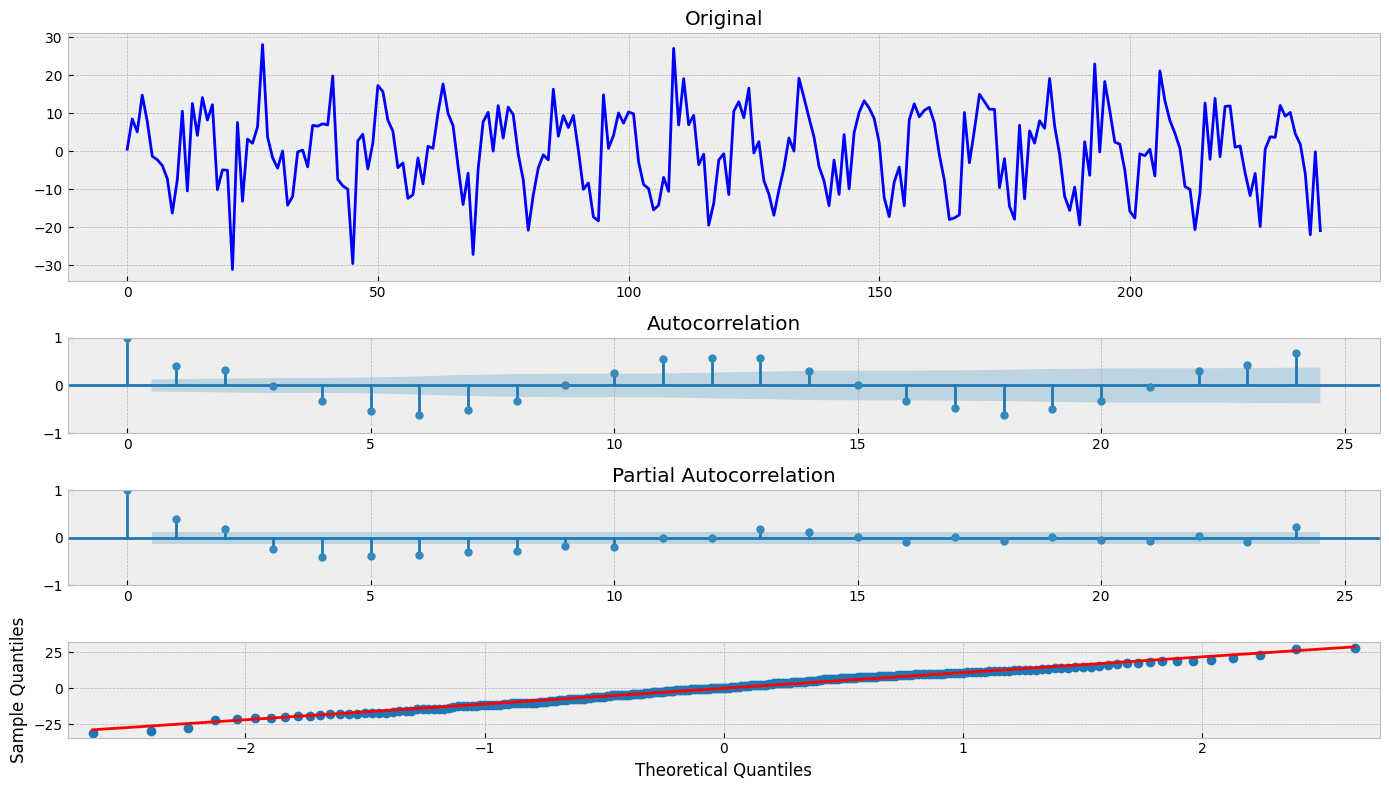

In [29]:
tsplot(res.resid)

## По простому

Такой подход является не совсем корректным (для прогнозирования свойств ВР), но он часто позволяет получать неплохие результаты в сжатые сроки

Генерируем большое количество фичей для нашего временного ряда

In [30]:
series = pd.read_csv("Series/international-airline-passengers.csv")

In [31]:
s = pd.DataFrame(series['Count'])
s.columns = ['curr_value']

window = 10
for i in range(1, window + 1):
    s.loc[:, f'prev_val_{i}'] = s['curr_value'].shift(i)

s.dropna(inplace=True)
s.head(5)

,curr_value,prev_val_1,prev_val_2,prev_val_3,prev_val_4,prev_val_5,prev_val_6,prev_val_7,prev_val_8,prev_val_9,prev_val_10
10,104,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
11,118,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
12,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
13,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
14,141,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0


In [32]:
def prepareData(data, lag_start=5, lag_end=20, test_size=0.15):
    
    data = pd.DataFrame(data.copy())
    
    # считаем индекс в датафрейме, после которого начинается тестовый отрезок
    test_index = int(len(data)*(1-test_size))
    
    # добавляем лаги исходного ряда в качестве признаков
    for i in range(lag_start, lag_end):
        data["lag_{}".format(i)] = data.Count.shift(i)
        
    data = data.dropna()
    data = data.reset_index(drop=True)
    data = data.drop(["Month"], axis=1)
     
    # разбиваем весь датасет на тренировочную и тестовую выборку
    X_train = data.loc[:test_index].drop(["Count"], axis=1)
    y_train = data.loc[:test_index]["Count"]
    X_test = data.loc[test_index:].drop(["Count"], axis=1)
    y_test = data.loc[test_index:]["Count"]
    
    return X_train, X_test, y_train, y_test

In [33]:
X_train, X_test, y_train, y_test = prepareData(series, lag_start=1, lag_end=20, test_size=0.3)

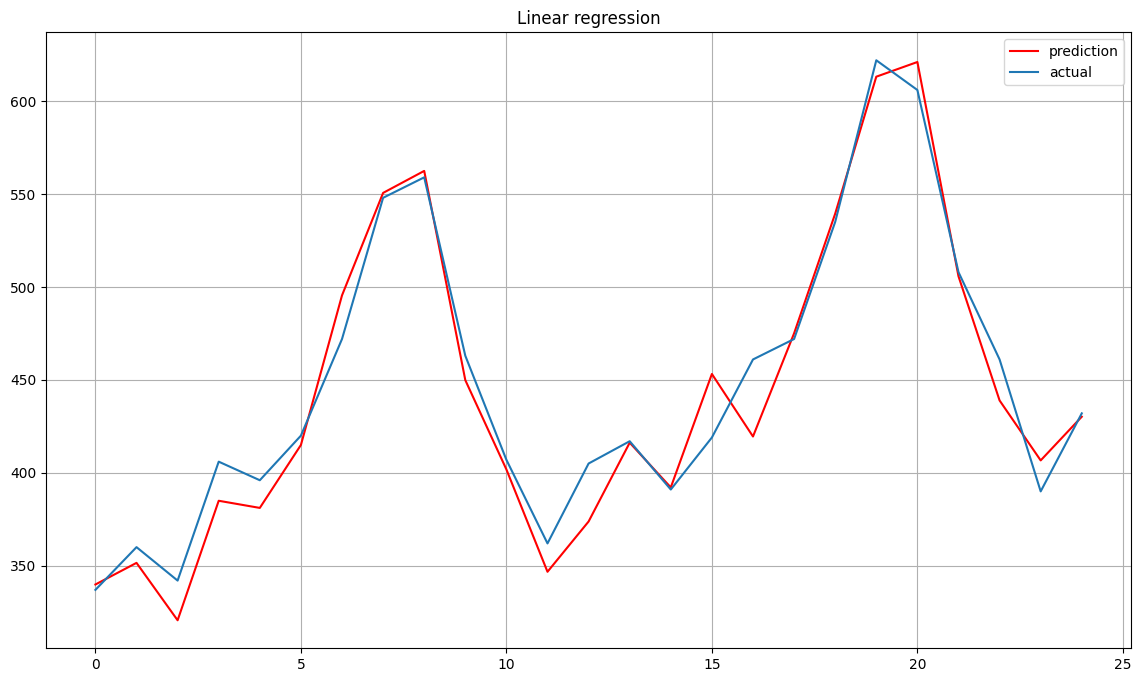

In [34]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
prediction = lr.predict(X_test)

plt.figure(figsize=(14, 8))
plt.plot(prediction, "r", label="prediction")
plt.plot(y_test.values, label="actual")
plt.legend(loc="best")
plt.title("Linear regression")
plt.grid(True);

# Домашнее задание
- Выберите ряд и постройте его модель GARCH.
- **Не обязательное дз.** Попробуйте спрогнозировать график классическим ML

Results of Dickey-Fuller Test:
Test Statistic                -1.214226e+01
p-value                        1.640728e-22
#Lags Used                     1.100000e+01
Number of Observations Used    2.270000e+02
Critical Value (1%)           -3.459490e+00
Critical Value (5%)           -2.874358e+00
Critical Value (10%)          -2.573602e+00
dtype: float64


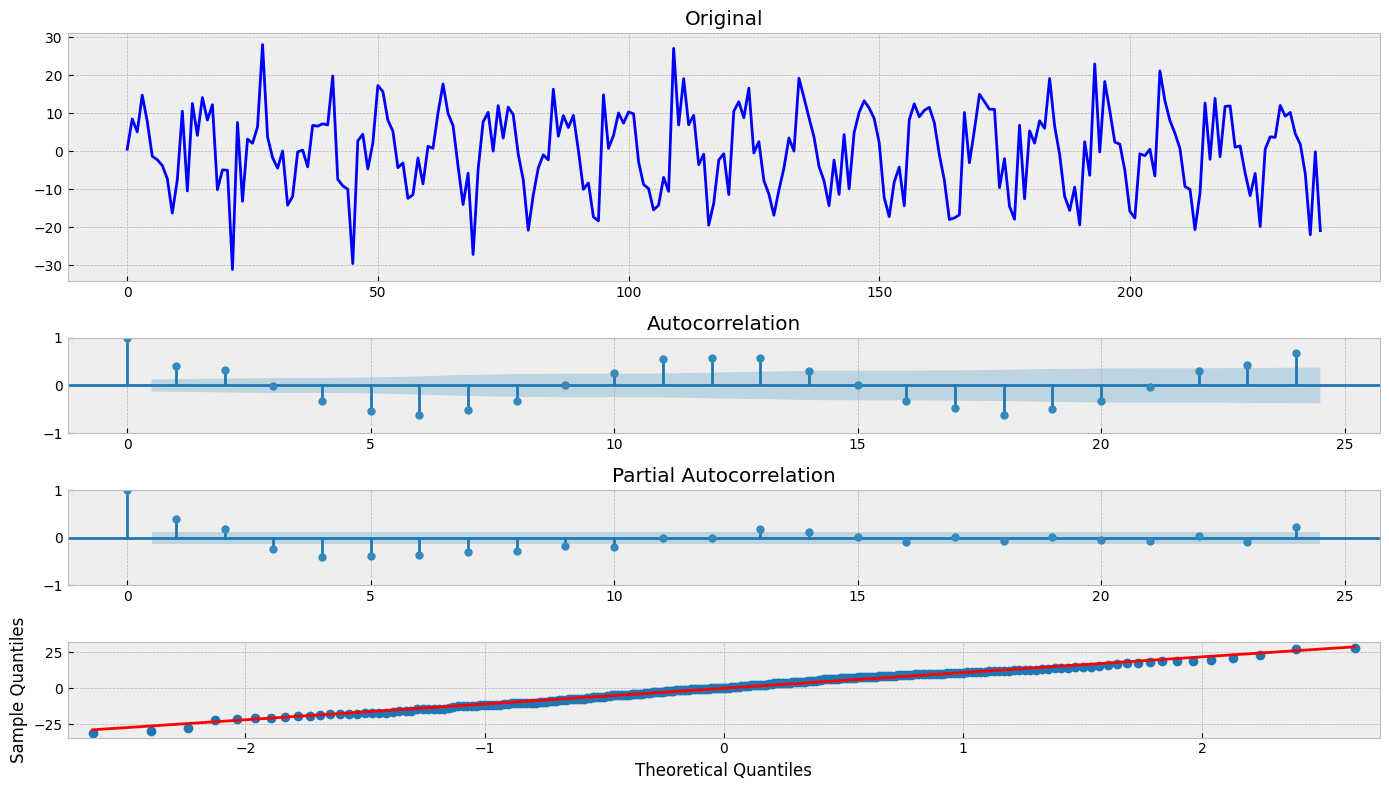

In [35]:
tsplot(res.resid)

**Вывод**

Для временного ряда mean-monthly-air-temperature-deg была построена модель ARIMA с автоматическим подбором параметров по критерию AIC.
После преобразования ряда (логарифмирование и дифференцирование) ряд стал стационарным, что подтверждается тестом Дики–Фуллера.
На основе преобразованного ряда была построена модель GARCH.
Анализ остатков показал уменьшение автокорреляции и стабилизацию дисперсии ошибок.
Модель GARCH подходит для описания волатильности данного временного ряда.

## Полезная информация
- https://people.duke.edu/~rnau/411home.htm
- https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-15-276
- http://www.blackarbs.com/blog/time-series-analysis-in-python-linear-models-to-garch/11/1/2016